shape: (30000, 24)
columns: Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3              

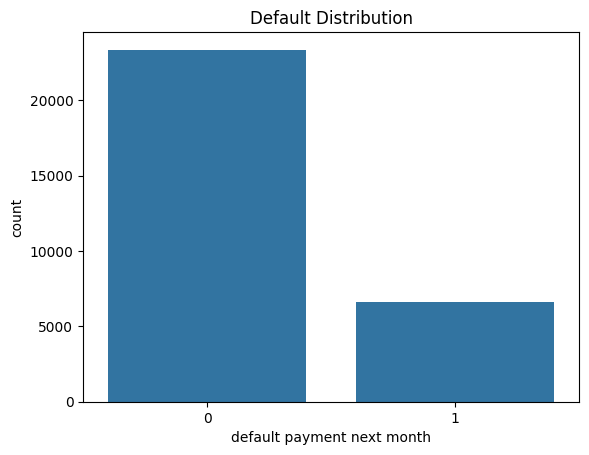

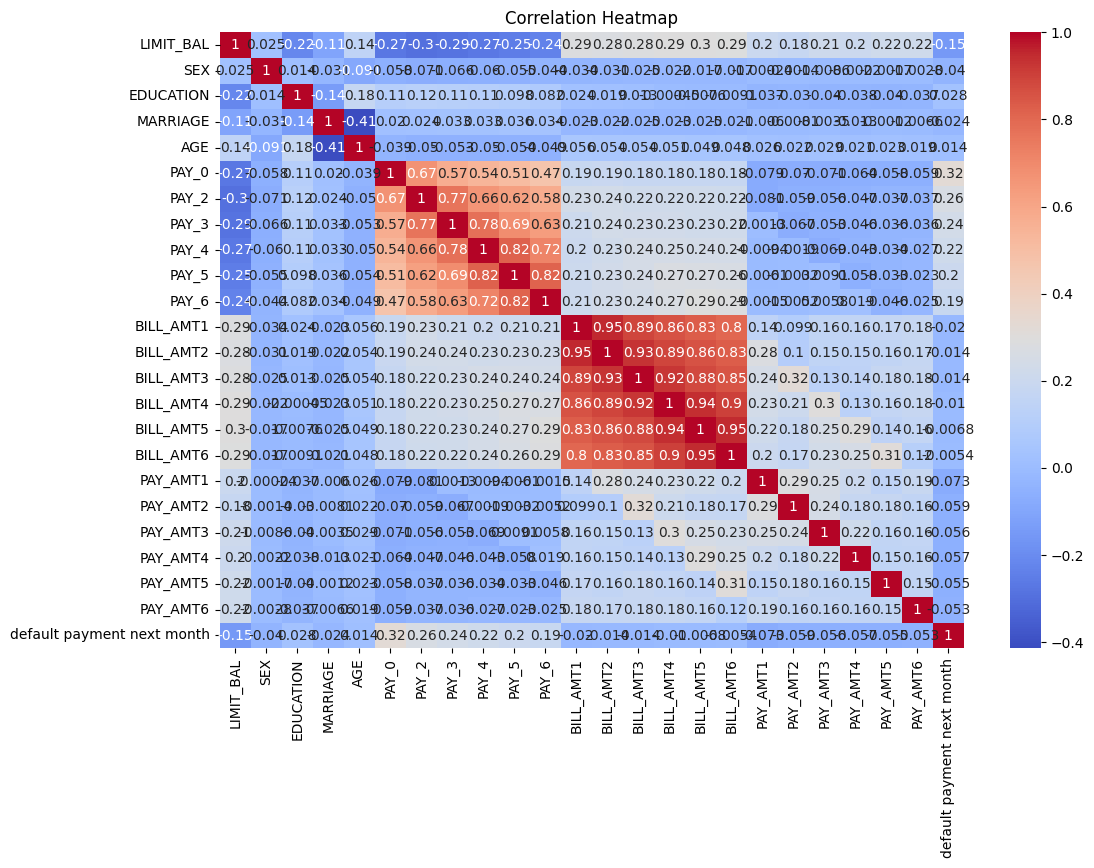

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:11:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameter: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.8166666666666667
ROC-AUC: 0.649202210392366

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



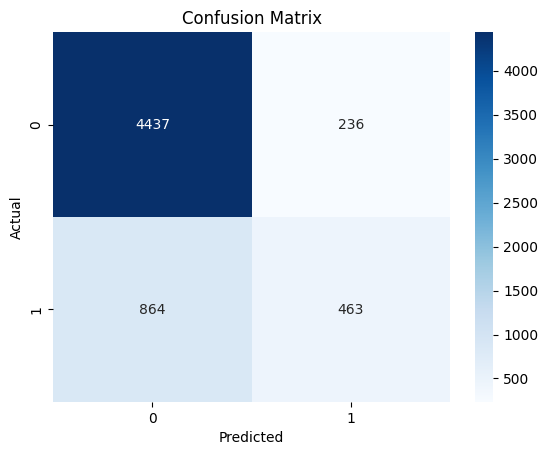

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile


!wget -q "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip" -O UCI_Credit_Card.csv.zip

with zipfile.ZipFile('UCI_Credit_Card.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df_excel = pd.read_excel('default of credit card clients.xls', header=1)
df_excel = df_excel.drop('ID', axis=1)


df_excel.to_csv('default of credit card clients.csv', index=False)


df = pd.read_csv('default of credit card clients.csv')

df.head()

print("shape:", df.shape)
print("columns:", df.columns)
df.info()
df.describe()

df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

sns.countplot(x='default payment next month', data=df) # Corrected column name
plt.title('Default Distribution')
plt.show()



plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


df['TOTAL_BILL'] = (
    df['BILL_AMT1'] +
    df['BILL_AMT2'] +
    df['BILL_AMT3'] +
    df['BILL_AMT4'] +
    df['BILL_AMT5'] +
    df['BILL_AMT6']
)


df['TOTAL_PAY'] = (
    df['PAY_AMT1'] +
    df['PAY_AMT2'] +
    df['PAY_AMT3'] +
    df['PAY_AMT4'] +
    df['PAY_AMT5'] +
    df['PAY_AMT6']
)


df['CREDIT_UTILIZATION'] = df['TOTAL_BILL'] / df['LIMIT_BAL']


df.replace([np.inf, -np.inf], 0, inplace=True)


x = df.drop('default payment next month', axis=1) # Corrected column name
y = df['default payment next month'] # Corrected column name


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42, stratify=y)


from sklearn.preprocessing import StandardScaler
import joblib


scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)


joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")
joblib.dump(scaler, "scaler.pkl")


joblib.dump(scaler, 'scaler.pkl')

import joblib

X_train = joblib.load('X_train.pkl')
X_test = joblib.load('y_train.pkl')


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200,],
    'max_depth': [5, 10,None],
    'min_samples_split': [2,5]
}


grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,

)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameter:", grid.best_params_)


joblib.dump(best_rf, 'best_model.pkl')



import joblib
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")
model = joblib.load("best_model.pkl")


y_pred = model.predict(X_test)




print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




